In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-admission-records/student_admission_record_dirty.csv


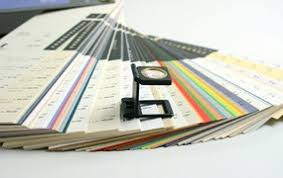
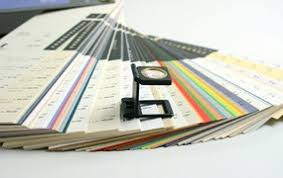

📝 Dataset Description:

The dataset contains information about students, their demographics, academic background, and admission outcomes. It can be used for exploratory data analysis, visualization, and predictive modeling to understand the factors influencing admission decisions.

📌 Features:

—Student’s
Age – Age of the student (numeric). Some values may contain errors (e.g., negative ages).

—Gender
Admission Test Score – The score obtained in the university admission test (numeric).

High School Percentage – Percentage obtained in high school (numeric, some missing values).

Residence


📊 Key Insights from the Dataset:

Students come from different cities, allowing comparison of performance by region.

Age distribution ranges mostly between late teens and early twenties, with some invalid values that may need cleaning.

Gender balance can be analyzed to check representation of male and female students.

Academic performance is represented by both high school percentage and admission test scores, which can be compared to see their effect on admission.

Admission Status provides a target variable for classification models (Accepted vs. Rejected).



✅ Usage:

This dataset is suitable for:

gender, and
Visualization (scatterplots, histograms, bar charts, pie charts, heatmaps).

Predictive modeling (e.g., predicting admission chances based on test score and high school performance).

Data cleaning practice (handling missing values, correcting errors like negative age).

**>Use This Data**

In [2]:
file_path = "/kaggle/input/student-admission-records/student_admission_record_dirty.csv"

Explore Data

In [3]:
df = pd.read_csv(file_path)
print(df)

        Name   Age  Gender  Admission Test Score  High School Percentage  \
0    Shehroz  24.0  Female                  50.0                   68.90   
1      Waqar  21.0  Female                  99.0                   60.73   
2     Bushra  17.0    Male                  89.0                     NaN   
3      Aliya  17.0    Male                  55.0                   85.29   
4      Bilal  20.0    Male                  65.0                   61.13   
..       ...   ...     ...                   ...                     ...   
152      Ali  19.0  Female                  85.0                   78.09   
153    Bilal  17.0  Female                  81.0                   84.40   
154   Fatima  21.0  Female                  98.0                   50.86   
155   Shoaib  -1.0    Male                  91.0                   80.12   
156     Maaz  17.0    Male                  88.0                   86.85   

          City Admission Status  
0       Quetta         Rejected  
1      Karachi     

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    147 non-null    object 
 1   Age                     147 non-null    float64
 2   Gender                  147 non-null    object 
 3   Admission Test Score    146 non-null    float64
 4   High School Percentage  146 non-null    float64
 5   City                    147 non-null    object 
 6   Admission Status        147 non-null    object 
dtypes: float64(3), object(4)
memory usage: 8.7+ KB
None


Missing values

In [5]:
df.isnull().sum()

Name                      10
Age                       10
Gender                    10
Admission Test Score      11
High School Percentage    11
City                      10
Admission Status          10
dtype: int64

Cleaning Data

In [6]:
df["Name"].fillna("Unknown", inplace=True)

/tmp/ipykernel_13/626038248.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Name"].fillna("Unknown", inplace=True)


In [7]:
df.loc[df["Age"] <= 0, "Age"] = np.nan

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)


In [8]:
df["Age"].fillna(df["Age"].median(), inplace=True)

/tmp/ipykernel_13/2097741607.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)


In [9]:
print(df["Gender"].value_counts())

Gender
Female    83
Male      64
Name: count, dtype: int64


In [10]:
gender_mode = df["Gender"].mode()[0]

In [11]:
df["Gender"].fillna(gender_mode,inplace=True)

/tmp/ipykernel_13/3931548717.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Gender"].fillna(gender_mode,inplace=True)


In [12]:
df.loc[(df["Admission Test Score"] < 0) | (df["Admission Test Score"] > 100) , "Admission Test Score"] = np.nan

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


In [13]:
df["Admission Test Score"].fillna(df["Admission Test Score"].mean(), inplace=True)

/tmp/ipykernel_13/4157356378.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Admission Test Score"].fillna(df["Admission Test Score"].mean(), inplace=True)


In [14]:
df.loc[(df["High School Percentage"] < 0) | (df["High School Percentage"] > 100), "High School Percentage"] = np.nan

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


In [15]:
df["High School Percentage"].fillna(df["High School Percentage"].mean(), inplace=True)

/tmp/ipykernel_13/2098289834.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["High School Percentage"].fillna(df["High School Percentage"].mean(), inplace=True)


In [16]:
df["City"].fillna("Unknown", inplace=True)

/tmp/ipykernel_13/4032887332.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["City"].fillna("Unknown", inplace=True)


In [17]:
df["Admission Status"].fillna("Pending",inplace=True)

/tmp/ipykernel_13/3709803760.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Admission Status"].fillna("Pending",inplace=True)


In [18]:
df.isnull().sum()

Name                      0
Age                       0
Gender                    0
Admission Test Score      0
High School Percentage    0
City                      0
Admission Status          0
dtype: int64

In [19]:
print(df.head(10))

      Name   Age  Gender  Admission Test Score  High School Percentage  \
0  Shehroz  24.0  Female             50.000000               68.900000   
1    Waqar  21.0  Female             99.000000               60.730000   
2   Bushra  17.0    Male             89.000000               76.037986   
3    Aliya  17.0    Male             55.000000               85.290000   
4    Bilal  20.0    Male             65.000000               61.130000   
5  Murtaza  23.0  Female             77.566434               76.037986   
6     Asad  18.0    Male             77.566434               97.310000   
7    Rabia  20.0  Female             82.000000               55.670000   
8   Rohail  17.0    Male             64.000000               76.037986   
9   Kamran  18.0    Male             53.000000               98.980000   

        City Admission Status  
0     Quetta         Rejected  
1    Karachi          Pending  
2  Islamabad         Accepted  
3    Karachi         Rejected  
4     Lahore          Pen

Data Analysis 

In [20]:
df.describe()

,Age,Admission Test Score,High School Percentage
count,157.000000,157.000000,157.000000
mean,20.369427,77.566434,76.037986
std,2.262534,13.536067,15.014310
min,17.000000,50.000000,0.000000
25%,19.000000,71.000000,67.030000
50%,20.000000,77.566434,76.037986
75%,22.000000,89.000000,86.850000
max,24.000000,99.000000,99.800000


In [21]:
df.groupby("Gender")["Admission Test Score"].mean()

Gender
Female    79.171667
Male      75.233829
Name: Admission Test Score, dtype: float64

In [22]:
df.groupby("Admission Status")["High School Percentage"].mean()


Admission Status
Accepted    77.176309
Pending     61.847000
Rejected    76.841788
Name: High School Percentage, dtype: float64

In [23]:
df.groupby(["Gender", "Admission Status"])["Name"].count()

Gender  Admission Status
Female  Accepted            46
        Pending              3
        Rejected            44
Male    Accepted            25
        Pending              7
        Rejected            32
Name: Name, dtype: int64

 visualisations 

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

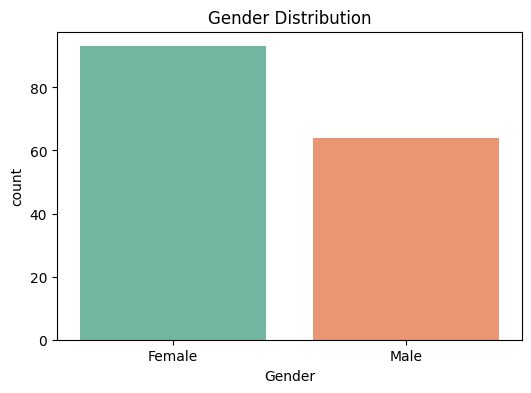

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender",palette="Set2")
plt.title("Gender Distribution")
plt.show

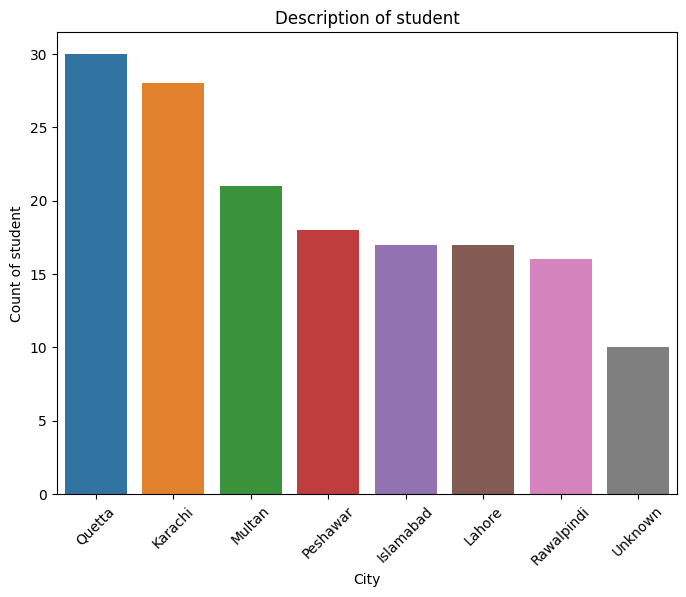

In [26]:
plt.figure(figsize=(8,6))
sns.countplot(
    data=df,
    x=("City"),
    order=df["City"].value_counts().index,
)
plt.title("Description of student")
plt.xlabel("City")
plt.ylabel("Count of student")
plt.xticks(rotation=45)
plt.show()

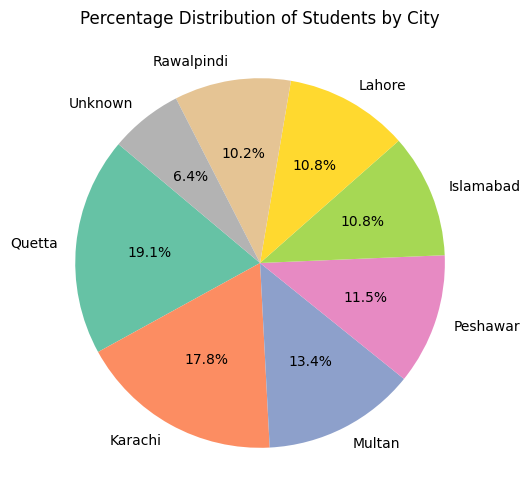

In [27]:
plt.figure(figsize=(6,6))
city_counts = df["City"].value_counts()
plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("Set2", len(city_counts))
)
plt.title("Percentage Distribution of Students by City")
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


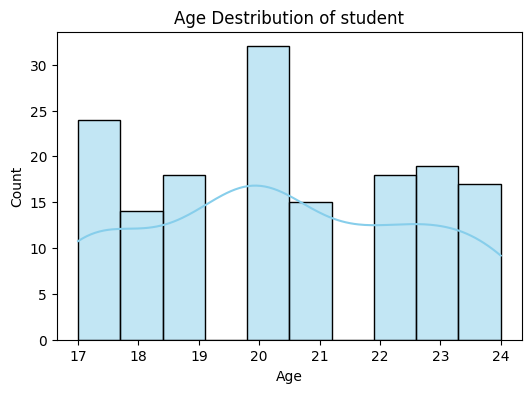

In [28]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=10, kde=True, color="skyblue")
plt.title("Age Destribution of student")
plt.show()

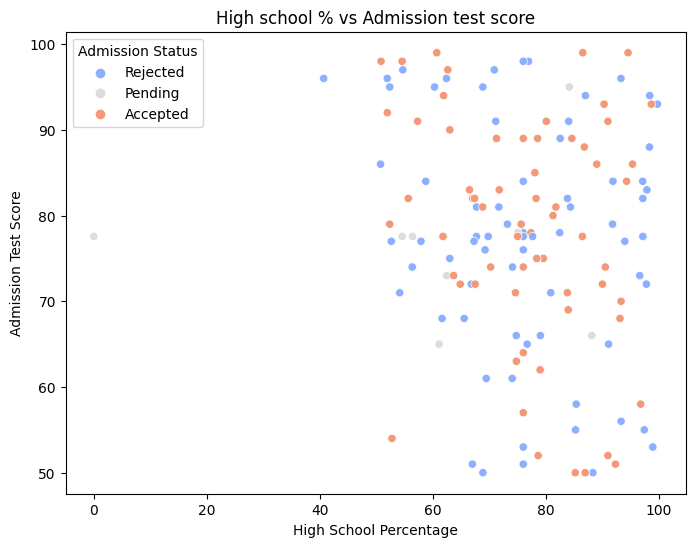

In [29]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="High School Percentage",
    y="Admission Test Score",
    hue="Admission Status",
    palette="coolwarm"
)
plt.title("High school % vs Admission test score")
plt.show()

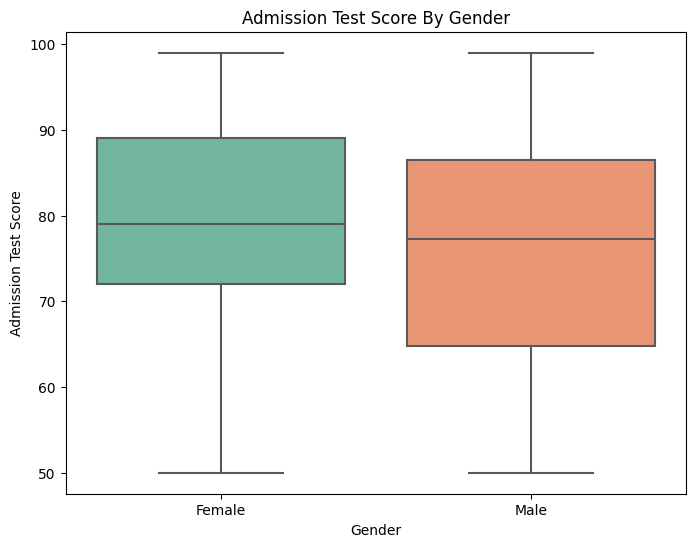

In [30]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="Gender", y="Admission Test Score", palette="Set2")
plt.title("Admission Test Score By Gender")
plt.show()

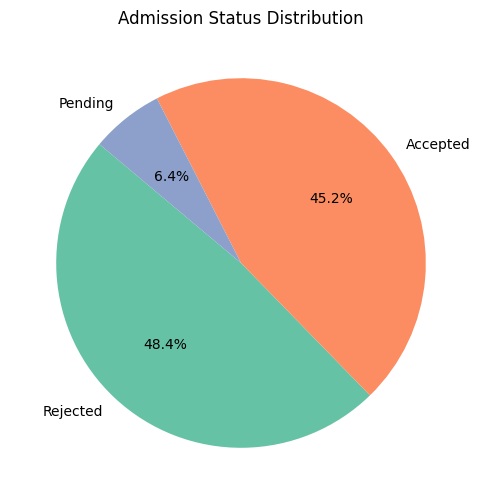

In [31]:
plt.figure(figsize=(6,6))
status_counts = df["Admission Status"].value_counts()
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("Set2", len(status_counts))
)
plt.title("Admission Status Distribution")
plt.show()


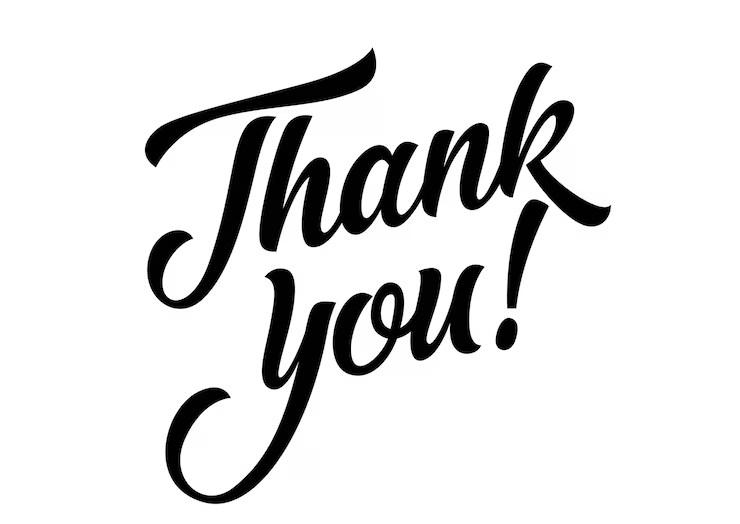
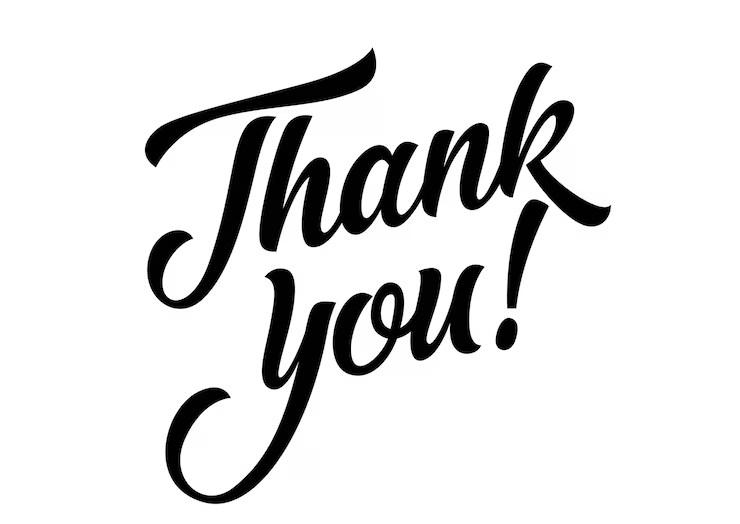